## Objective of project
The project aims to analyze customer churn in a telecommunications company and develop predictive models to identify at-risk customers.<br>
The ultimate goal is to provide actionable insights and improve customer retention.<br>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


## Task 1

In [2]:
# 1.Load the dataset using pandas
df=pd.read_csv("C:/Users/mahvi/Downloads/Telco_Customer_Churn_Dataset  (3).csv")


## Data Description 
The dataset contains customer information from a telecom company, including demographics, sevice subscriptions, account details, billing information and a churn flag indicating whether a customer has left the service.<br>
It helps analyze customer behaviour and identify key factors contributing to customer churn.<br>

In [3]:
df.shape


(7043, 21)

In [4]:
#2.Display the first 10 rows
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
#3.Identify the datatypes of each column
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

## Insights:
TotalCharges data type is wrong.<br>

In [7]:
#4.Checking for missing value
df.eq(" ").sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

## TASK 2


Cleaning and converting datatype
since Total Charges data type is object and contained empty value (" ") value so replacing " " with nan and data type to numeric. 

In [8]:
df.replace({" ":np.nan},inplace=True)


In [9]:
df.loc[:,'TotalChargesNew']=df.loc[:,'TotalCharges'].astype('float64')

In [10]:
df.loc[:,'TotalChargesNew'].dtypes

dtype('float64')

In [11]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
TotalChargesNew     float64
dtype: object

In [12]:
df.drop('TotalCharges',axis=1,inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
TotalChargesNew     11
dtype: int64

In [15]:
(df.isnull().mean()*100)

customerID          0.000000
gender              0.000000
SeniorCitizen       0.000000
Partner             0.000000
Dependents          0.000000
tenure              0.000000
PhoneService        0.000000
MultipleLines       0.000000
InternetService     0.000000
OnlineSecurity      0.000000
OnlineBackup        0.000000
DeviceProtection    0.000000
TechSupport         0.000000
StreamingTV         0.000000
StreamingMovies     0.000000
Contract            0.000000
PaperlessBilling    0.000000
PaymentMethod       0.000000
MonthlyCharges      0.000000
Churn               0.000000
TotalChargesNew     0.156183
dtype: float64

In [16]:
cols=[var for var in df.columns if df[var].isnull().mean()<0.05 and df[var].isnull().mean()>0]

In [17]:
cols

['TotalChargesNew']

In [18]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,TotalChargesNew
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,No,1889.50
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes,108.15
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No,1840.75
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,No,1990.50
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,No,7362.90
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,No,346.45
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,Yes,306.60


In [19]:
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


Exploratory Data Analysis (EDA)

In [20]:
df.shape

(7043, 21)

In [21]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

In [22]:
X=df.drop(columns=['Churn'])
y=df['Churn']

In [23]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [24]:
X_train.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalChargesNew
4169,3663-MITLP,Female,0,No,No,15,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,101.25,1457.25
3571,8980-WQFWL,Female,0,No,No,35,Yes,No,DSL,No,No,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,62.10,2096.10
1352,7722-VJRQD,Male,0,Yes,Yes,72,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),60.95,4549.05
1278,4730-AWNAU,Male,0,Yes,Yes,36,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,No,Credit card (automatic),60.70,2234.55
938,2692-AQCPF,Female,0,Yes,No,65,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,One year,Yes,Credit card (automatic),108.05,7118.90


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results=[]

param_grid={
    'classifier__C':[0.01,0.1,1,10,100]    
}

def evaluate_model(X_train,X_test,y_train,y_test,preprocessor,method):

    pipe=Pipeline([
        ('preprocessor',preprocessor),
        ('classifier',LogisticRegression(max_iter=1000))
    ])

    grid=GridSearchCV(
        pipe,
        param_grid=param_grid,
        cv=5,
        scoring='f1',
        n_jobs=-1
    )

    grid.fit(X_train,y_train)
    
    y_pred=grid.predict(X_test)
    y_prob=grid.predict_proba(X_test)[:,1]

    results.append([
        method,
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred),
        recall_score(y_test,y_pred),
        f1_score(y_test,y_pred),
        roc_auc_score(y_test,y_prob),
        grid.best_params_
    ])

In [28]:
cat_transformer=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])

In [29]:
df_cca=df.dropna()

X=df_cca.drop('Churn',axis=1)
y = df_cca['Churn'].map({'No':0,'Yes':1})

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,
    random_state=2,
    stratify=y
)

num_cols=X_train.select_dtypes(include=['int64','float64']).columns
cat_cols=X_train.select_dtypes(include='object').columns

num_transformer=Pipeline([
    ('scaler',StandardScaler())
])

preprocessor_cca=ColumnTransformer([
    ('num',num_transformer,num_cols),
    ('cat',cat_transformer,cat_cols)
])

evaluate_model(X_train,X_test,y_train,y_test,
               preprocessor_cca,'CCA')

In [31]:
num_transformer=Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

preprocessor_median=ColumnTransformer([
    ('num',num_transformer,num_cols),
    ('cat',cat_transformer,cat_cols)
])

evaluate_model(X_train,X_test,y_train,y_test,
               preprocessor_median,'Median')

In [33]:
from sklearn.base import BaseEstimator, TransformerMixin

class RandomSampleImputer(BaseEstimator, TransformerMixin):

    def fit(self,X,y=None):
        self.samples_={}
        for col in X.columns:
            self.samples_[col]=X[col].dropna()
        return self

    def transform(self,X):
        X=X.copy()

        for col in X.columns:
            mask=X[col].isnull()

            X.loc[mask,col]=self.samples_[col].sample(
                mask.sum(),
                replace=True,
                random_state=2
            ).values

        return X

In [34]:
num_transformer=Pipeline([
    ('imputer',RandomSampleImputer()),
    ('scaler',StandardScaler())
])

preprocessor_random=ColumnTransformer([
    ('num',num_transformer,num_cols),
    ('cat',cat_transformer,cat_cols)
])

evaluate_model(X_train,X_test,y_train,y_test,
               preprocessor_random,'Random Sample')

In [35]:
class EndTailImputer(BaseEstimator,TransformerMixin):

    def fit(self,X,y=None):
        self.fill_ = X.quantile(.95)
        return self

    def transform(self,X):
        return X.fillna(self.fill_)

In [36]:
num_transformer=Pipeline([
    ('imputer',EndTailImputer()),
    ('scaler',StandardScaler())
])

preprocessor_eod=ColumnTransformer([
    ('num',num_transformer,num_cols),
    ('cat',cat_transformer,cat_cols)
])

evaluate_model(X_train,X_test,y_train,y_test,
               preprocessor_eod,
               'End Distribution')

In [37]:
num_transformer=Pipeline([
    ('imputer',SimpleImputer(strategy='median',
                             add_indicator=True)),
    ('scaler',StandardScaler())
])

preprocessor_indicator=ColumnTransformer([
    ('num',num_transformer,num_cols),
    ('cat',cat_transformer,cat_cols)
])

evaluate_model(X_train,X_test,y_train,y_test,
               preprocessor_indicator,
               'Missing Indicator')

In [38]:
from sklearn.impute import KNNImputer

num_transformer=Pipeline([
    ('imputer',KNNImputer(n_neighbors=5)),
    ('scaler',StandardScaler())
])

preprocessor_knn=ColumnTransformer([
    ('num',num_transformer,num_cols),
    ('cat',cat_transformer,cat_cols)
])

evaluate_model(X_train,X_test,y_train,y_test,
               preprocessor_knn,
               'KNN')

In [39]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

num_transformer=Pipeline([
    ('imputer',IterativeImputer(random_state=42)),
    ('scaler',StandardScaler())
])

preprocessor_mice=ColumnTransformer([
    ('num',num_transformer,num_cols),
    ('cat',cat_transformer,cat_cols)
])

evaluate_model(X_train,X_test,y_train,y_test,
               preprocessor_mice,
               'MICE')

In [40]:
comparison=pd.DataFrame(
    results,
    columns=[
        'Method',
        'Accuracy',
        'Precision',
        'Recall',
        'F1-score',
        'ROC-AUC',
        'Best Parameters'
    ]
)

comparison.sort_values(
    by='F1-score',
    ascending=False,
    inplace=True
)

print(comparison)

              Method  Accuracy  Precision    Recall  F1-score  ROC-AUC  \
0                CCA  0.793888    0.62963  0.545455  0.584527  0.85458   
1             Median  0.793888    0.62963  0.545455  0.584527  0.85458   
2      Random Sample  0.793888    0.62963  0.545455  0.584527  0.85458   
3   End Distribution  0.793888    0.62963  0.545455  0.584527  0.85458   
4  Missing Indicator  0.793888    0.62963  0.545455  0.584527  0.85458   
5                KNN  0.793888    0.62963  0.545455  0.584527  0.85458   
6               MICE  0.793888    0.62963  0.545455  0.584527  0.85458   

        Best Parameters  
0  {'classifier__C': 1}  
1  {'classifier__C': 1}  
2  {'classifier__C': 1}  
3  {'classifier__C': 1}  
4  {'classifier__C': 1}  
5  {'classifier__C': 1}  
6  {'classifier__C': 1}  


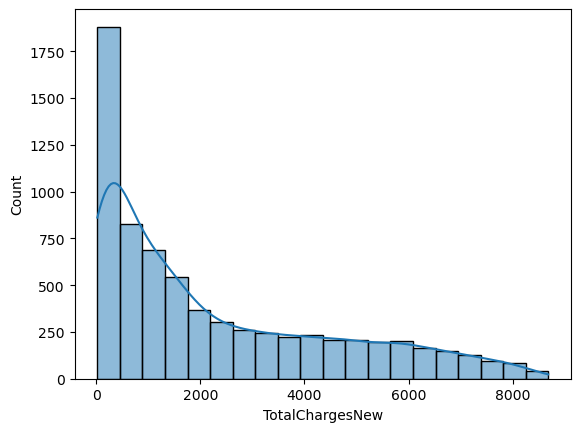

In [21]:
# distribution of TotalChargesNew to fill nan value
sns.histplot(df['TotalChargesNew'],bins=20,kde=True)
plt.show()

In [22]:
# TotalChargesNew is positively skewed so replacing empty cell with median value
df.loc[:,"TotalChargesNew"].fillna(0.0,inplace=True)

In [23]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
Churn               0
TotalChargesNew     0
dtype: int64

In [24]:
# Standardizing column names(converting to lowercase and replacing spaces with underscores).
df.columns=df.columns.str.lower().str.replace(" ","_")
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'churn', 'totalchargesnew'],
      dtype='object')

## TASK3

### Exploratory Data Analysis (EDA)

In [25]:
col1=df.select_dtypes(include=['float64','int64'])
col1

,seniorcitizen,tenure,monthlycharges,totalchargesnew
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65
...,...,...,...,...
7038,0,24,84.80,1990.50
7039,0,72,103.20,7362.90
7040,0,11,29.60,346.45
7041,1,4,74.40,306.60


In [26]:
# Generate summary statistics(mean, median, mode)
df.describe()

,seniorcitizen,tenure,monthlycharges,totalchargesnew
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [27]:
col2=df.select_dtypes(include=['object'])
col2.columns

Index(['customerid', 'gender', 'partner', 'dependents', 'phoneservice',
       'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup',
       'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies',
       'contract', 'paperlessbilling', 'paymentmethod', 'churn'],
      dtype='object')

In [28]:
df.describe(include=['object'])


,customerid,gender,partner,dependents,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [29]:
list=[ 'gender', 'partner', 'dependents', 'phoneservice',
       'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup',
       'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies',
       'contract', 'paperlessbilling', 'paymentmethod', 'churn']
for x in list:
    print(x,df[x].unique())
    print()

gender ['Female' 'Male']

partner ['Yes' 'No']

dependents ['No' 'Yes']

phoneservice ['No' 'Yes']

multiplelines ['No phone service' 'No' 'Yes']

internetservice ['DSL' 'Fiber optic' 'No']

onlinesecurity ['No' 'Yes' 'No internet service']

onlinebackup ['Yes' 'No' 'No internet service']

deviceprotection ['No' 'Yes' 'No internet service']

techsupport ['No' 'Yes' 'No internet service']

streamingtv ['No' 'Yes' 'No internet service']

streamingmovies ['No' 'Yes' 'No internet service']

contract ['Month-to-month' 'One year' 'Two year']

paperlessbilling ['Yes' 'No']

paymentmethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

churn ['No' 'Yes']



Replaced "No internet service"/"No phone service"  with "No" across relevant service columns, since these represent the same underlying condition 

In [30]:
# columns that contain "No internet service" as a redundant category
internet_dependent_cols=['onlinesecurity','onlinebackup','deviceprotection','techsupport','streamingtv','streamingmovies']
for col in internet_dependent_cols:
    df[col]=df[col].replace('No internet service','No')

# multiplelines has a similar issue with "No phone service"
df["multiplelines"]=df["multiplelines"].replace('No phone service','No')

#verify-each should now show only ['no', 'yes']
for x in internet_dependent_cols + ["multiplelines"]:
    print(x,df[x].unique())
    


onlinesecurity ['No' 'Yes']
onlinebackup ['Yes' 'No']
deviceprotection ['No' 'Yes']
techsupport ['No' 'Yes']
streamingtv ['No' 'Yes']
streamingmovies ['No' 'Yes']
multiplelines ['No' 'Yes']


### Create visualization for numerical columns

## univariate analysis

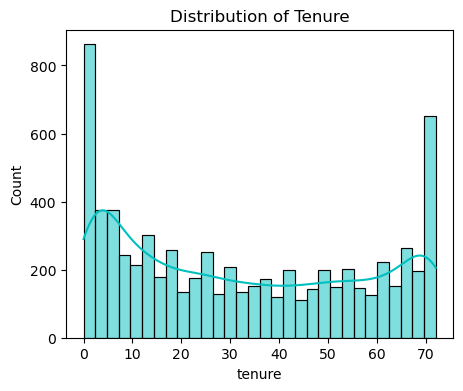

In [31]:
plt.figure(figsize=(5,4))
sns.histplot(df["tenure"], bins=30, color='c', kde=True)
plt.title("Distribution of Tenure")
plt.show()

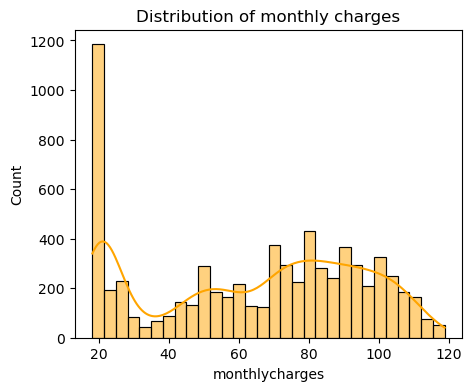

In [32]:
plt.figure(figsize=(5,4))
sns.histplot(df["monthlycharges"], bins=30, color='orange',kde=True)
plt.title("Distribution of monthly charges")
plt.show()

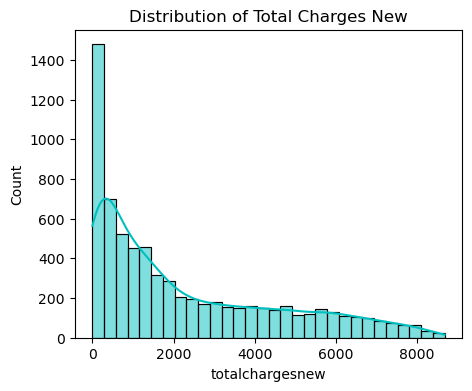

In [33]:
plt.figure(figsize=(5,4))
sns.histplot(df["totalchargesnew"], bins=30, color='c',kde=True)
plt.title("Distribution of Total Charges New")
plt.show()

Correlation Heatmap for numerical columns

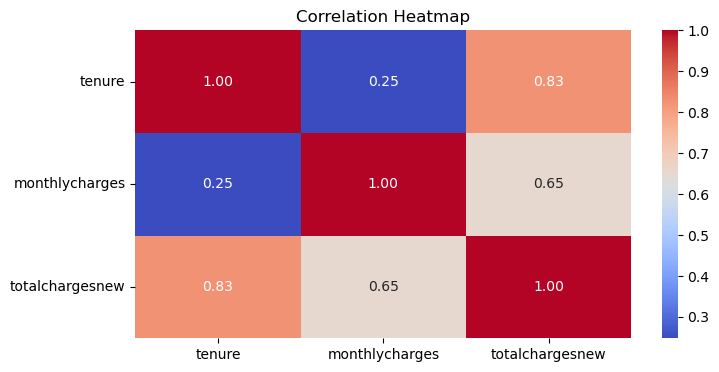

In [34]:
# correlation matrix - heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(df[["tenure", "monthlycharges", "totalchargesnew"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

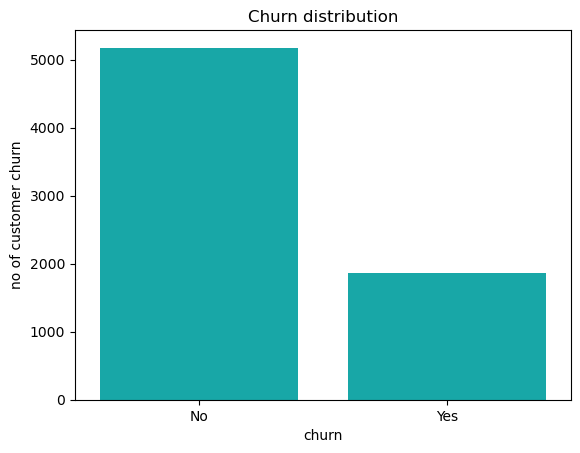

In [35]:
sns.countplot(df, x="churn",color='c')
plt.title("Churn distribution")
plt.ylabel("no of customer churn")
plt.show()

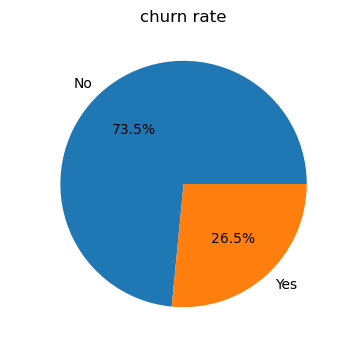

In [36]:
# Analysing churn rate
plt.figure(figsize=(5,4))
df['churn'].value_counts().plot(kind='pie',autopct="%0.1f%%")
plt.title("churn rate")
plt.ylabel(" ")
plt.show()

# Insights:
**Customer Retention:** A large propotion of customers continue using the service, indicating relatively strong retention.<br>
**Churn Rate:** A significant portion of customers have churned,which suggest areas for improvements in customer satisfaction or service quality.<br>
**Improvemant:** Reducing churn rate could lead to better customer loyalty and more stable revenue streams.<br>
**Action Required:** The company could benefit targeted efforts to understand and address the reasons behind the churn.<br>    


## TASK 4

In [37]:
#1.Visualize customer distribution by tenure using pie chart
def tenure_group(tenure):
    if tenure <= 12:
        return "0-12 months"
    elif tenure <= 36:
        return "13-36 months"
    else:
        return "37+ months"

df['tenure_group'] = df['tenure'].apply(tenure_group)

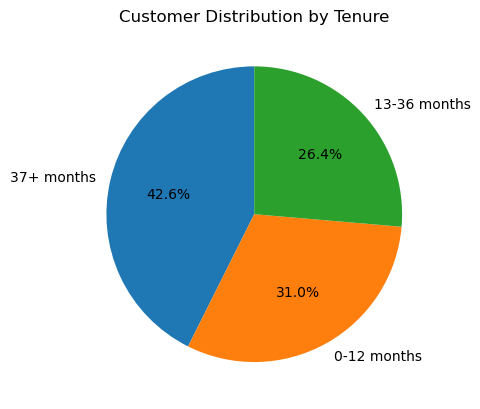

In [38]:
tenure_counts = df['tenure_group'].value_counts()

plt.figure()
plt.pie(tenure_counts, labels=tenure_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Customer Distribution by Tenure")
plt.show()

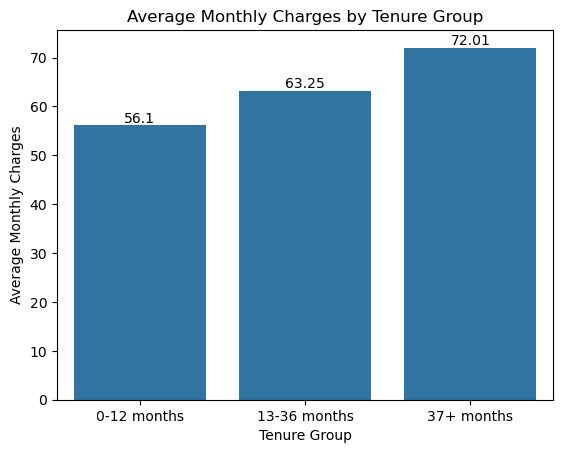

In [39]:
#2.Using clustered bar chart to compare average monthly charges across tenure
avg_charges = df.groupby('tenure_group')['monthlycharges'].mean().reset_index()

plt.figure()
sns.barplot(data=avg_charges, x='tenure_group', y='monthlycharges')

plt.title("Average Monthly Charges by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Average Monthly Charges")

# Annotations
for index, row in avg_charges.iterrows():
    plt.text(index, row['monthlycharges'], round(row['monthlycharges'], 2),
             ha='center', va='bottom')

plt.show()

In [40]:
import plotly.express as px

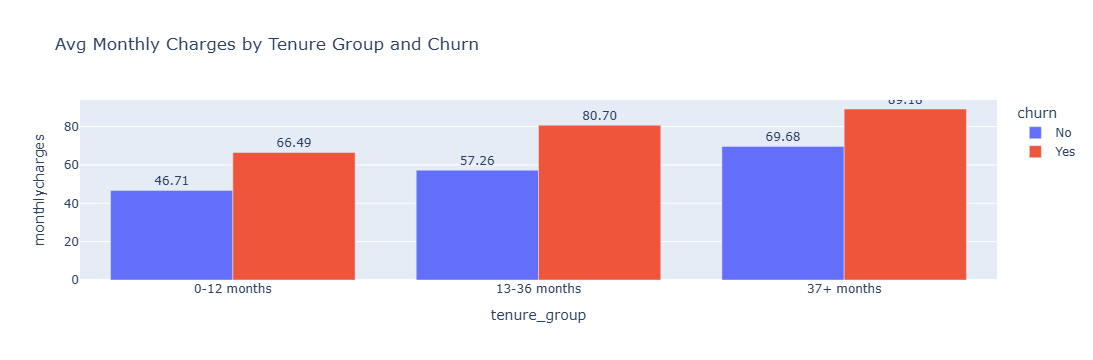

In [41]:
#3.Adding annotations(tenure + churn)
avg_charges_churn = df.groupby(['tenure_group', 'churn'])['monthlycharges'].mean().reset_index()

fig = px.bar(
    avg_charges_churn,
    x='tenure_group',
    y='monthlycharges',
    color='churn',
    barmode='group',
    title="Avg Monthly Charges by Tenure Group and Churn",
    text='monthlycharges'
)

fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')

fig.show()

# Insight:
1.Across all tenure groups, churned customers have consistently higher average monthly charges than reatained customers--suggesting price is a key churn driver, not just tenure alone.<br>
2.A significant portion of customers fall in the 0–12 months category, indicating many new or recently acquired users. While the churn customer is more than non churn customers in 0-12 months tenure.<br>
3.The gap is more pronounced in the 13-36 months group indicating customers who haven't yet locked into long-term value may be more sensitive to high charges.The 13–36 months segment acts as a transition phase, where customers either churn or become loyal.<br>
4.Even long-tenure customers(37+ months) show this pattern, meaning high charges can still trigger churn even after years of loyalty.<br>
**Suggestions** The business may be acquiring customers well, but retaining them beyond the first year is critical. Investigate whether higher-paying customers are on plans with poor perceived value. Consider loyalty discounts or bundled offers for high-paying customers, especially in the 13-36 month window where the churn-charge gap is widest.<br>

### TASK 5

## bivariate analysis

In [42]:
# Convert Churn to numeric
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})

In [43]:
df.head(3)

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,churn,totalchargesnew,tenure_group
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,0,29.85,0-12 months
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,0,1889.50,13-36 months
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,1,108.15,0-12 months


In [44]:
#1.Grouping customer by tenure to compute statistics for charges and churn
group_stats = df.groupby('tenure_group').agg({'monthlycharges': ['mean', 'min', 'max'],'totalchargesnew': ['mean'],'churn': ['mean']  # churn rate
}).reset_index()

group_stats.columns = ['tenure_group', 'avg_monthlycharges', 'min_monthlycharges', 'max_monthlycharges',
                       'avg_totalchargesnew', 'churn_rate_mean']

print(group_stats)

   tenure_group  avg_monthlycharges  min_monthlycharges  max_monthlycharges  \
0   0-12 months           56.097781               18.75              112.95   
1  13-36 months           63.248195               18.25              116.25   
2    37+ months           72.008730               18.40              118.75   

   avg_totalchargesnew  churn_rate_mean  
0           275.229597         0.474382  
1          1513.541756         0.255388  
2          4213.723192         0.119294  


# Insight:
Customers in different tenure groups show variation in average monthly charges.<br>
1.Average monthly charges increase with tenure (Rs.56.09-->Rs.63.24-->Rs.72.00), while churn rate drops sharply across the same groups (47.4%-->25.5%-->11.9%).<br>
2.This shows higher charges alone don't drive churn--long-tenure customers pay more but stay, likely due to accumulated value or satisfaction.<br>
3.The 0-12 month group is highest risk (47.4% churn) despite paying the lowest charges, pointing to early-stage onboarding or service issues as the real driver, not price.<br>
**Suggestions:** Prioritize retention efforts in the first 12 months regardless of price tier--this is where the company loses nearly half its customers. Consider onboarding improvements or early loyalty incentives rather than discounting.<br>
**Improvements:** 
Pricing strategies and plans evolve over the customer lifecycle.<br>
Monitoring pricing vs tenure helps identify when customers are most vulnerable to churn.<br>

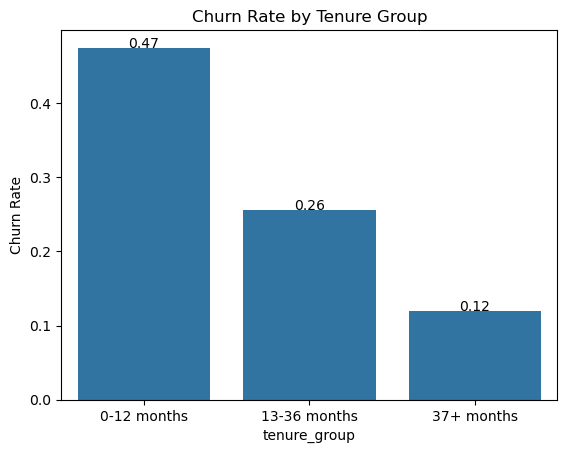

In [45]:
#1(a) Visualize churn rate by Tenure
plt.figure()
sns.barplot(data=group_stats, x='tenure_group', y='churn_rate_mean')

plt.title("Churn Rate by Tenure Group")
plt.ylabel("Churn Rate")

# Annotation
for i, row in group_stats.iterrows():
    plt.text(i, row['churn_rate_mean'], f"{row['churn_rate_mean']:.2f}", ha='center')

plt.show()

# Insights
Early-stage customers (0–12 months) are the most critical segment to engage and retain.<br>
Mid-tenure customers (13–36 months) represent an opportunity for upselling.<br>
Long-tenure customers (37+) are loyal but should be nurtured to prevent late churn.<br>


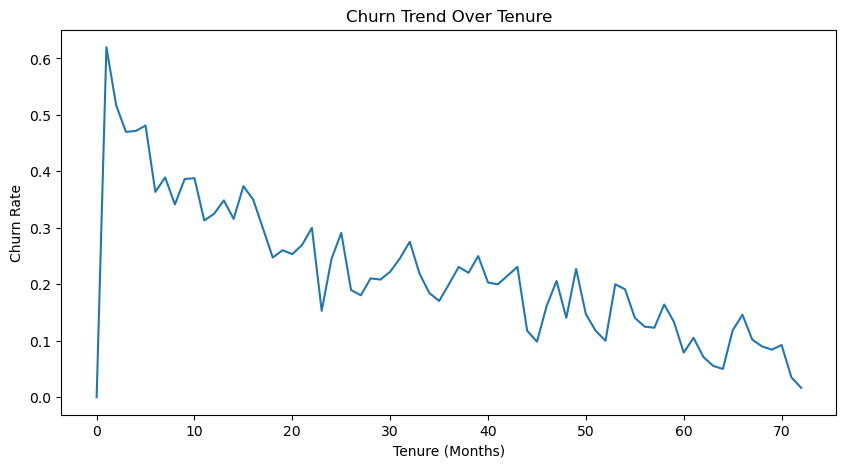

In [46]:
#1(b).Visualize trend over life cycle stages
trend = df.groupby('tenure')['churn'].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(trend['tenure'], trend['churn'])

plt.title("Churn Trend Over Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate")
plt.show()

## Insight:
Customers in the 0–12 months group show the highest churn rate.<br>
Churn steadily decreases as tenure increases, with the 37+ months group being the most stable.<br>
**Action:** Early-stage customers are the most vulnerable. The first year is the critical churn window, where retention efforts should be concentrated.<br>

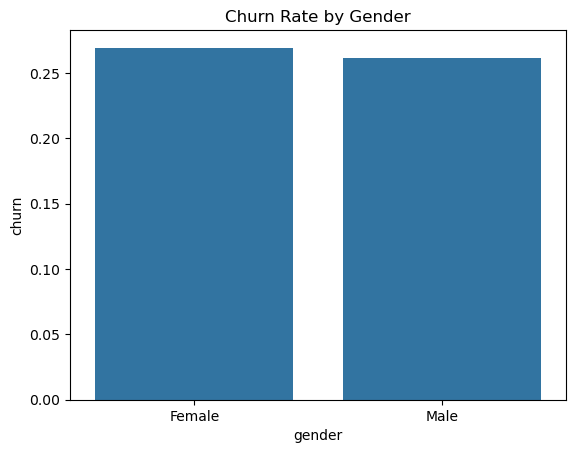

In [47]:
#2(a).Analyse churn rate by Demographics--Gender
gender_churn = df.groupby('gender')['churn'].mean().reset_index()

sns.barplot(data=gender_churn, x='gender', y='churn')
plt.title("Churn Rate by Gender")
plt.show()

## Insight:
Churn rates between genders are usually very similar.<br>
Gender is not a strong predictor of churn.<br>

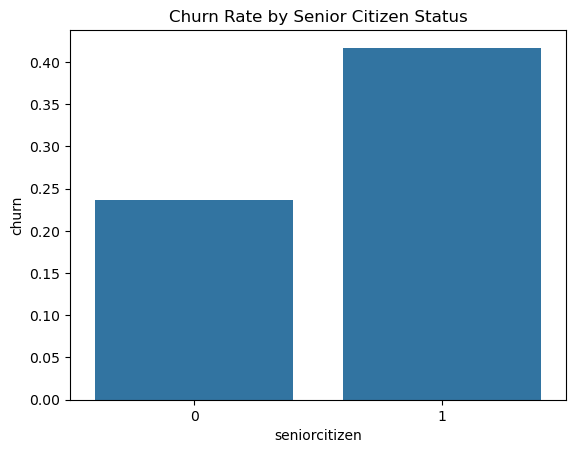

In [48]:
#2(b).Analyse churn rate by Demographics--Senior Citizen Status
senior_churn = df.groupby('seniorcitizen')['churn'].mean().reset_index() #Yes -1, No- 0

sns.barplot(data=senior_churn, x='seniorcitizen', y='churn')
plt.title("Churn Rate by Senior Citizen Status")
plt.show()

## Insight:
Senior citizens often have a slightly higher churn rate.<br>
This segment may require more personalized support or simpler plans.<br>

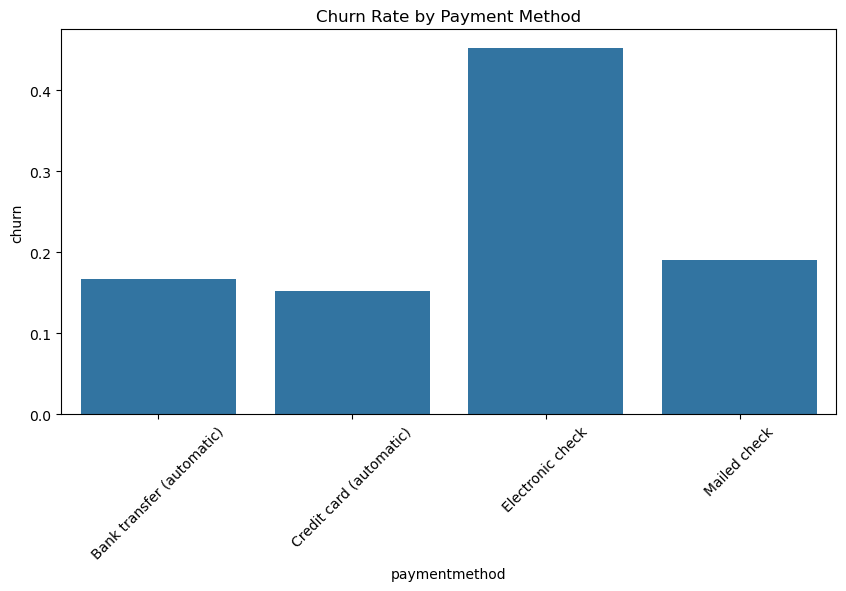

In [49]:
#3(a).Analyse churn rate by Demographics--Payment Method
payment_churn = df.groupby('paymentmethod')['churn'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=payment_churn, x='paymentmethod', y='churn')
plt.xticks(rotation=45)
plt.title("Churn Rate by Payment Method")
plt.show()

## Insight:
Customers using electronic check typically exhibit higher churn rates.<br>
Automatic payment methods (credit card, bank transfer) show lower churn.<br>
**Action:** Payment friction or customer profile differences may influence churn. Promoting auto-pay options can help reduce churn.<br>

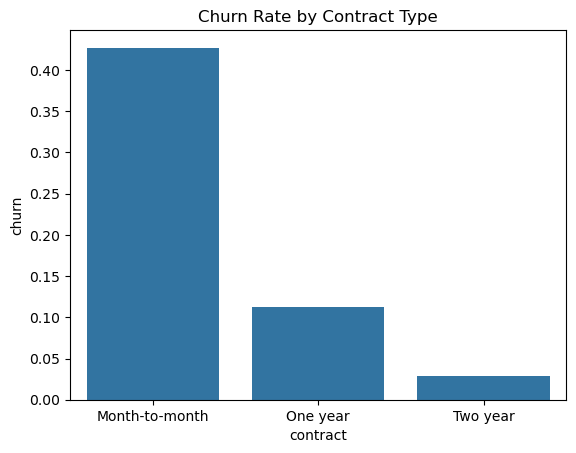

In [50]:
#3(b).Analyse churn rate by Demographics--Contract Type
contract_churn = df.groupby('contract')['churn'].mean().reset_index()

sns.barplot(data=contract_churn, x='contract', y='churn')
plt.title("Churn Rate by Contract Type")
plt.show()

## Insight:
Month-to-month contracts have the highest churn rates.<br>
One-year and two-year contracts show significantly lower churn.<br>
**Action:** Contract commitment strongly reduces churn. Encouraging customers to switch from monthly to long-term contracts can improve retention.

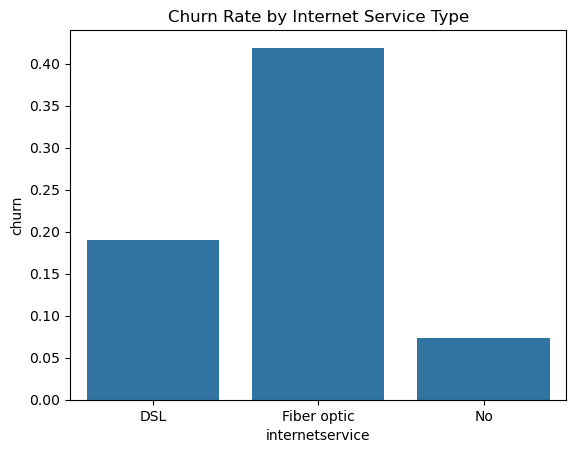

In [51]:
#3(c).Analyse churn rate by Demographics--Internet Service
internet_service = df.groupby('internetservice')['churn'].mean().reset_index()
sns.barplot(data=internet_service, x='internetservice', y='churn')
plt.title("Churn Rate by Internet Service Type")
plt.show()

## Insight:
Fiber optic customers churn more than DSL customers despite being a premium product.<br>
**Recommendation:** Investigate pricing complaints or service quality issues specific to fiber.

## TASK 6

## Revenue Impact Analysis

In [52]:
# Revenue lost to churn
monthly_revenue_lost= df.loc[df['churn']== 1,'monthlycharges'].sum()
total_monthly_revenue= df['monthlycharges'].sum()
pct_at_risk=(monthly_revenue_lost/total_monthly_revenue)*100
annual_revenue_lost= monthly_revenue_lost * 12
print(f"Monthly revenue lost to churn: Rs {monthly_revenue_lost:,.2f}")
print(f"Total monthly revenue: Rs {total_monthly_revenue:,.2f}")
print(f"% of revenue at risk: {pct_at_risk:.2f}%")
print(f"Esimated annual revenue lost: Rs {annual_revenue_lost:,.2f}")

Monthly revenue lost to churn: Rs 139,130.85
Total monthly revenue: Rs 456,116.60
% of revenue at risk: 30.50%
Esimated annual revenue lost: Rs 1,669,570.20


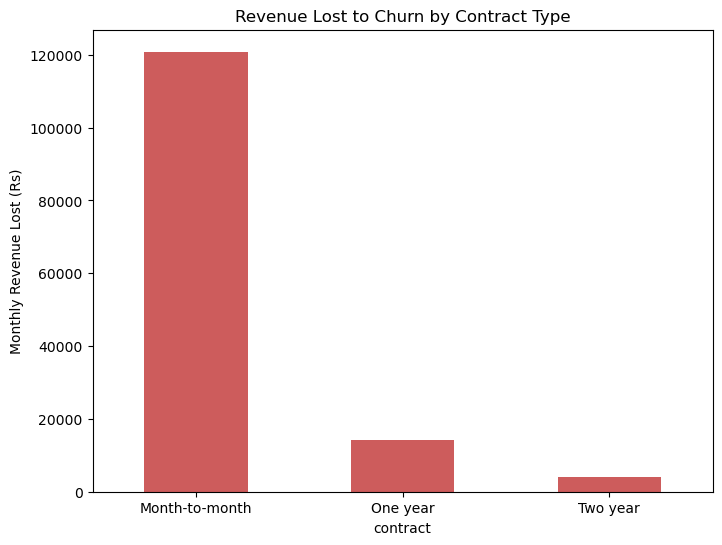

contract
Month-to-month    120847.10
One year           14118.45
Two year            4165.30
Name: monthlycharges, dtype: float64

In [53]:
# ===== Revenue lost by Contract type (which segment hurts most) =====
revenue_by_contract = df[df['churn']== 1].groupby('contract')['monthlycharges'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,6))
revenue_by_contract.plot(kind='bar', color='indianred')
plt.ylabel("Monthly Revenue Lost (Rs)")
plt.title("Revenue Lost to Churn by Contract Type")
plt.xticks(rotation=0)
plt.show()

revenue_by_contract

## High-Risk Segment Identification(multi-factor)

In [54]:
# ===== Combined risk segments =====
risk_segment = df.groupby(['contract', 'internetservice', 'paymentmethod'])['churn'].agg(['mean', 'count'])
risk_segment.columns = ['churn_rate', 'customer_count']
risk_segment['churn_rate'] = (risk_segment['churn_rate'] * 100).round(2)

# Filter out small segments (noise) — keep only segments with enough customers
risk_segment = risk_segment[risk_segment['customer_count'] >= 30]
risk_segment_sorted = risk_segment.sort_values('churn_rate', ascending=False)
risk_segment_sorted.head(10)

churn_rate  \
contract       internetservice paymentmethod                           
Month-to-month Fiber optic     Electronic check                60.37   
                               Mailed check                    50.75   
                               Bank transfer (automatic)       45.57   
                               Credit card (automatic)         41.64   
               DSL             Electronic check                40.51   
                               Mailed check                    30.79   
                               Credit card (automatic)         27.03   
One year       Fiber optic     Electronic check                26.02   
Month-to-month No              Mailed check                    20.62   
                               Bank transfer (automatic)       20.00   

                                                          customer_count  
contract       internetservice paymentmethod                              
Month-to-month Fiber optic     Electronic check                     1307  
                               Mailed check                          201  
                               Bank transfer (automatic)             327  
                               Credit card (automatic)               293  
               DSL             Electronic check                      474  
                               Mailed check                          367  
                               Credit card (automatic)               185  
One year       Fiber optic     Electronic check                      196  
Month-to-month No              Mailed check                          325  
                               Bank transfer (automatic)              65

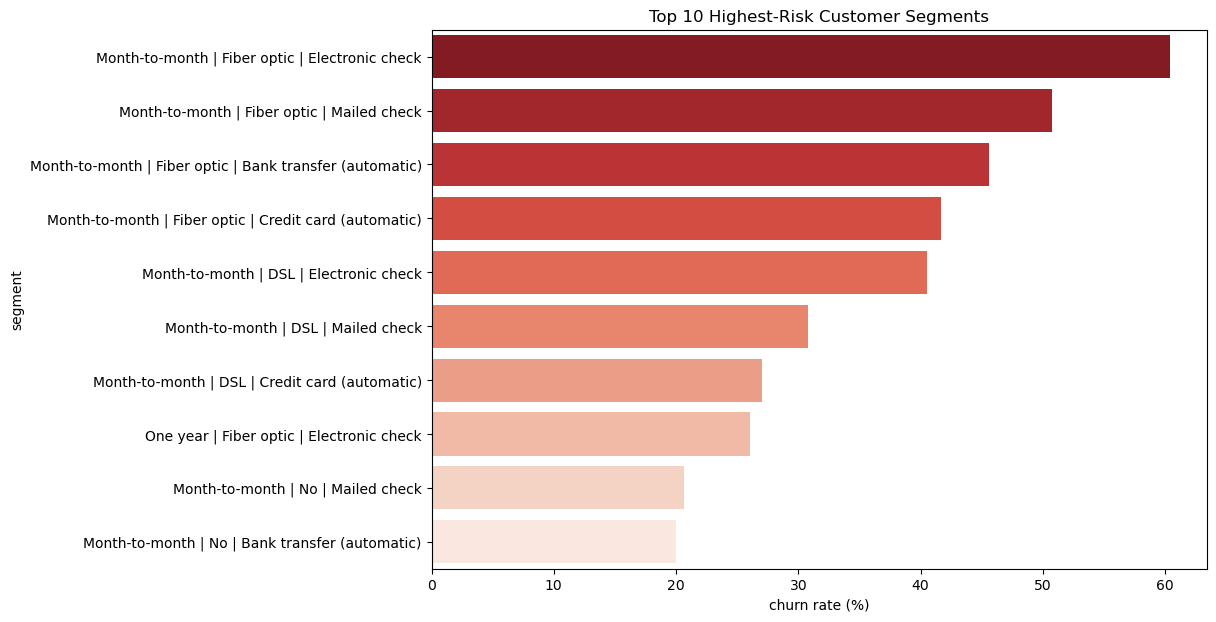

In [55]:
# ===== Visualize top 10 riskiest segments =====
top10 = risk_segment_sorted.head(10).reset_index()
top10['segment'] = top10['contract'] + ' | ' + top10['internetservice'] + ' | ' + top10['paymentmethod']

plt.figure(figsize=(10, 7))
sns.barplot(x='churn_rate', y='segment', data=top10, palette='Reds_r')
plt.xlabel("churn rate (%)")
plt.title("Top 10 Highest-Risk Customer Segments")
plt.show()

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

model_df = df.copy()

# 'churn' is already numeric (0/1), so exclude it from cat_cols encoding
cat_cols = model_df.select_dtypes(include='object').columns.drop(['customerID'], errors='ignore')

le = LabelEncoder()
for col in cat_cols:
    model_df[col] = le.fit_transform(model_df[col].astype(str))

X = model_df.drop(columns=['customerID', 'churn', 'tenure_group'], errors='ignore')
y = model_df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.838


# Insight :

The logistic regression model achieved a ROC-AUC of 0.838, indicating strong overall ability to separate churners from non-churners.<br>
Using class_weight='balanced' to address class imbalance improved recall on the churn class to 0.79, meaning the model catches most at-risk customers — the priority for a retention use case. This came at the cost of precision (0.50), so roughly half of flagged customers are false positives.<br>
This tradeoff is acceptable for a retention campaign, where the cost of missing a real churner (lost revenue) typically outweighs the cost of a false positive (an unnecessary retention offer to a loyal customer).

1 Cleaned and preprocessed a 7,000+ record telecom dataset,resolving **missing values** through root-cause analysis(tied to tenure=0); conducted univariate and bivariate analysis across 20+ features, uncovering an overall churn rate of **26.5%**.<br>
2 Identified the **highest-risk customer** segment through multi-factor analysis--Month-to-Month contracts with Fibre optic internet and Electronic check payments--showing a **60.37%** churn rate across 1,307 customers, more than 2x the baseline rate,enabling precision-targeted retention campaigns.<br>
3 **Quantified revenue impact of churn**, calculating **Rs1.39 lakh** in monthly and an estimated **Rs16.7 lakh** in annual revenue at risk (30.5% of total monthly revenue), converting churn analysis into board-ready financial terms for retention budget prioritization.<br>
4 Built and evaluated a **class-weighted logistic regression model** to predict churn drivers, achieving **0.838 ROC-AUC** and **79% recall** on at-risk customers, delivering an interpretable, deployable framework for proactive churn intervention.<br>


1Optimized telecom customer churn dataset by transforming features and selecting median imputation via 5-fold GridSearchCV, achieving 80.39% CV accuracy.
1 Evaluated multiple imputation strategies using 5-fold GridSearchCV and selected median imputation, achieving 80.39% cross-validation(CV) accuracy
2Conducted EDA and Uncovered high-risk segments through demographic, contract, and payment-method analysis, showing elevated churn among month-to-month.
3 Visualized customer lifecycle trends and identified a 74.9% reduction in churn risk from early-stage customers (47.4%) to long-tenure customers (11.9%), highlighting opportunities for targeted retention strategies.


In [106]:
df

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,churn,totalchargesnew,tenure_group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,0,29.85,0-12 months
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,0,1889.50,13-36 months
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,1,108.15,0-12 months
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,0,1840.75,37+ months
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,1,151.65,0-12 months
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,0,1990.50,13-36 months
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,0,7362.90,37+ months
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,0,346.45,0-12 months
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,1,306.60,0-12 months


In [107]:
print(df["churn"].value_counts())

churn
0    5174
1    1869
Name: count, dtype: int64


In [108]:
# identifying columns with object data type
object_columns = df.select_dtypes(include="object").columns

In [109]:
print(object_columns)

Index(['customerid', 'gender', 'partner', 'dependents', 'phoneservice',
       'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup',
       'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies',
       'contract', 'paperlessbilling', 'paymentmethod', 'tenure_group'],
      dtype='object')


In [110]:
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [111]:
# initialize a dictionary to save the encoders
encoders = {}

# apply label encoding and store the encoders
for column in object_columns:
  label_encoder = LabelEncoder()
  df[column] = label_encoder.fit_transform(df[column])
  encoders[column] = label_encoder



In [112]:
encoders

{'customerid': LabelEncoder(),
 'gender': LabelEncoder(),
 'partner': LabelEncoder(),
 'dependents': LabelEncoder(),
 'phoneservice': LabelEncoder(),
 'multiplelines': LabelEncoder(),
 'internetservice': LabelEncoder(),
 'onlinesecurity': LabelEncoder(),
 'onlinebackup': LabelEncoder(),
 'deviceprotection': LabelEncoder(),
 'techsupport': LabelEncoder(),
 'streamingtv': LabelEncoder(),
 'streamingmovies': LabelEncoder(),
 'contract': LabelEncoder(),
 'paperlessbilling': LabelEncoder(),
 'paymentmethod': LabelEncoder(),
 'tenure_group': LabelEncoder()}

In [113]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,churn,totalchargesnew,tenure_group
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,1,2,29.85,0,29.85,0
1,3962,1,0,0,0,34,1,0,0,2,...,0,0,0,1,0,3,56.95,0,1889.50,1
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,1,3,53.85,1,108.15,0
3,5535,1,0,0,0,45,0,1,0,2,...,2,0,0,1,0,0,42.30,0,1840.75,2
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,1,2,70.70,1,151.65,0


Traianing and test data split

In [114]:
# splitting the features and target
X = df.drop(columns=["churn"])
y = df["churn"]

In [115]:
# split training and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [116]:
print(y_train.shape)

(5634,)


In [117]:
print(y_train.value_counts())

churn
0    4138
1    1496
Name: count, dtype: int64


Synthetic Minority Oversampling TEchnique (SMOTE)

In [118]:
smote = SMOTE(random_state=42)

In [119]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [120]:
print(y_train_smote.shape)

(8276,)


In [121]:
print(y_train_smote.value_counts())

churn
0    4138
1    4138
Name: count, dtype: int64


Model Training

Training with default hyperparameters

In [122]:
# dictionary of models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

In [123]:
# dictionary to store the cross validation results
cv_scores = {}

# perform 5-fold cross validation for each model
for model_name, model in models.items():
  print(f"Training {model_name} with default parameters")
  scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring="accuracy")
  cv_scores[model_name] = scores
  print(f"{model_name} cross-validation accuracy: {np.mean(scores):.2f}")
  print("-"*70)

Training Decision Tree with default parameters
Decision Tree cross-validation accuracy: 0.78
----------------------------------------------------------------------
Training Random Forest with default parameters
Random Forest cross-validation accuracy: 0.85
----------------------------------------------------------------------
Training XGBoost with default parameters
XGBoost cross-validation accuracy: 0.84
----------------------------------------------------------------------


In [124]:
cv_scores

{'Decision Tree': array([0.69323671, 0.70755287, 0.83202417, 0.83746224, 0.84773414]),
 'Random Forest': array([0.73490338, 0.76435045, 0.90996979, 0.90271903, 0.9141994 ]),
 'XGBoost': array([0.70048309, 0.73716012, 0.90876133, 0.91238671, 0.92024169])}

Random Forest gives the highest accuracy compared to other models with default parameters

In [125]:
rfc = RandomForestClassifier(random_state=42)

In [126]:
rfc.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [127]:
print(y_test.value_counts())

churn
0    1036
1     373
Name: count, dtype: int64


Model Evaluation

In [128]:
# evaluate on test data
y_test_pred = rfc.predict(X_test)

print("Accuracy Score:\n", accuracy_score(y_test, y_test_pred))
print("Confsuion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))

Accuracy Score:
 0.7707594038325053
Confsuion Matrix:
 [[863 173]
 [150 223]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.83      0.84      1036
           1       0.56      0.60      0.58       373

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409



Built an end-to-end Customer Churn Prediction pipeline on 7,000+ telecom customer records, performing data cleaning, feature engineering, and exploratory data analysis to uncover churn patterns.
Implemented and compared 5+ missing value imputation techniques (Median, KNN, MICE, Random Sample, End-Tail) and optimized preprocessing using Scikit-learn Pipelines and GridSearchCV.
Handled class imbalance using SMOTE, improving model learning on minority churn cases and enhancing prediction reliability.
Developed and evaluated multiple machine learning models including Logistic Regression, Decision Tree, Random Forest, and XGBoost using 5-fold cross-validation and metrics such as Accuracy, F1-Score, Precision, Recall, and ROC-AUC.
Generated actionable business insights through 20+ visualizations and customer segmentation analysis, identifying churn trends based on tenure, contract type, payment method, and monthly charges to support retention strategies.